In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [85]:
df=pd.read_csv('weight-height.csv')

In [86]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


Text(0, 0.5, 'Height')

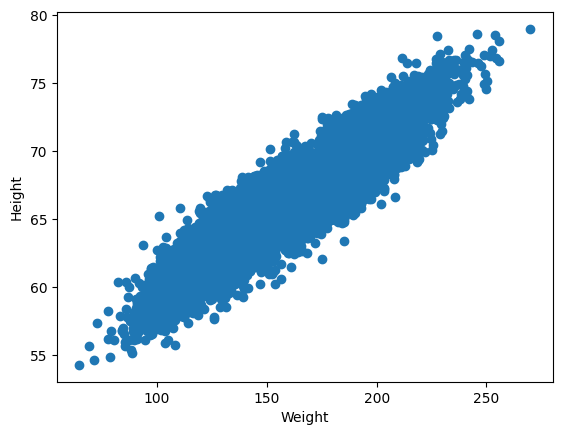

In [87]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [88]:
df.corr()

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


In [89]:
import seaborn as sns


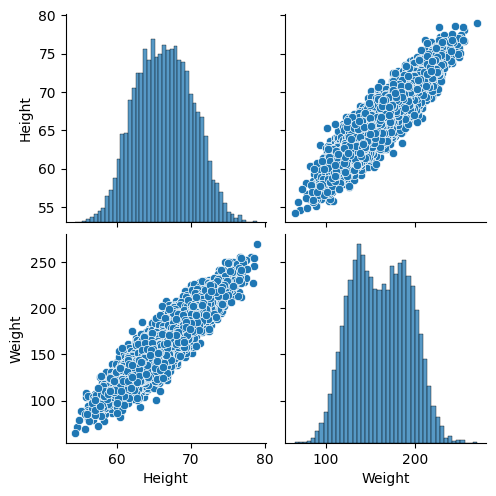

In [90]:
sns.pairplot(df)

In [91]:
X=df[['Weight']]
X.head()

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801


In [92]:
Y=df['Height']
Y.head()

0    73.847017
1    68.781904
2    74.110105
3    71.730978
4    69.881796
Name: Height, dtype: float64

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=45)

In [95]:
X_train

,Weight
4643,226.736155
2390,181.321297
6162,131.305434
8678,153.068001
6944,146.801099
...,...
8772,122.147714
163,203.350339
6012,99.494824
6558,115.677892


In [96]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [97]:
scaler.fit_transform(X_train)

array([[ 2.03177909],
       [ 0.61744436],
       [-0.94017744],
       ...,
       [-1.93084115],
       [-1.42685903],
       [-0.65692555]], shape=(8000, 1))

In [98]:
scaler.transform(X_test)

array([[ 1.17994604],
       [ 0.12760004],
       [-0.61942715],
       ...,
       [ 0.14433651],
       [-0.41373727],
       [ 0.43444574]], shape=(2000, 1))

In [99]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [100]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.11]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Weight']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,48.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [101]:
print("Coefficient is:",regression.coef_)
print("Intercept is:",regression.intercept_)

Coefficient is: [0.11096413]
Intercept is: 48.44252787995592


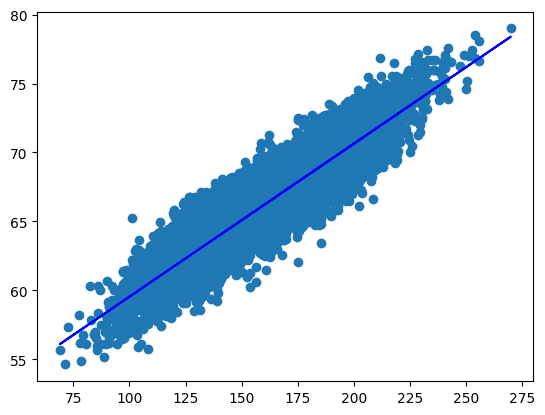

In [104]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train),color='blue')

In [107]:
Y_pred=regression.predict(X_test)

In [108]:
##Performanance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [116]:
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
print("Mean Squared error is:",mse)
print("Mean Absolute error is:",mae)
print("RMAE is:",rmse)

Mean Squared error is: 2.1588313173247293
Mean Absolute error is: 1.1709289800804241
RMAE is: 1.4692961979549015


In [118]:
##Performanance metrics
from sklearn.metrics import r2_score


In [ ]:
r2_score=r2_score()

In [119]:
##OLS Linear Regression
import statsmodels.api as sn


In [124]:
model=sn.OLS(X_train,Y_train).fit()

In [125]:
pred=model.predict(X_test)
print(pred)

4132    488.737116
6553    405.906572
7604    347.107784
585     454.528849
5924    384.197130
           ...    
193     534.901220
7500    316.704172
2949    407.223906
9842    363.297711
2025    430.058511
Length: 2000, dtype: float64


In [126]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Weight   R-squared (uncentered):                   0.979
Model:                            OLS   Adj. R-squared (uncentered):              0.979
Method:                 Least Squares   F-statistic:                          3.788e+05
Date:                Fri, 07 Aug 2026   Prob (F-statistic):                        0.00
Time:                        16:19:25   Log-Likelihood:                         -36668.
No. Observations:                8000   AIC:                                  7.334e+04
Df Residuals:                    7999   BIC:                                  7.335e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Height         2.4512      0.004    615.452      0.000       2.443       2.459
==============================================================================
Omnibus:                      763.501   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              227.386
Skew:                           0.014   Prob(JB):                     4.20e-50
Kurtosis:                       2.175   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [128]:
##Prediction for new data
regression.predict([[20]])

c:\Users\HOME\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([50.66181044])